# 資料科學 視覺化作業

對鳶尾花資料集進行資料視覺化，檔案格式已經整理好如下：

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #繪圖美化套件
from sklearn import datasets #載入sk資料集

In [ ]:
# 讀取檔案並整理資料格式
iris = datasets.load_iris()
# 1.轉換為data frame
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
# 2.將lable加入data frame的最後一欄
iris_df.loc[:, "species_label"] = iris.target
# 3.將編碼類別轉換為名稱，並加入dataframe中
species_name = np.where(iris_df["species_label"]==0,'setosa','-')
species_name[iris_df["species_label"]==1] = 'versicolor'
species_name[iris_df["species_label"]==2] = 'virginica'
iris_df['species_name'] = species_name
# 4.更改column name
iris_df.columns = ['SepalLengthCm', 'SepalWidthCm',	'PetalLengthCm',	'PetalWidthCm',	'species_label', 'species_name']
iris_df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,species_label,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virgin
146,6.3,2.5,5.0,1.9,2,virgin
147,6.5,3.0,5.2,2.0,2,virgin
148,6.2,3.4,5.4,2.3,2,virgin


Hints: 
1. `iris_df.SepalLengthCm` 可直接以序列方式存取SepalLengthCm特徵
2. `list()`可將資料型態轉換為list

## 第一題

針對SepalLengthCm特徵繪製直方圖(histogram)

Text(0, 0.5, 'Amount')

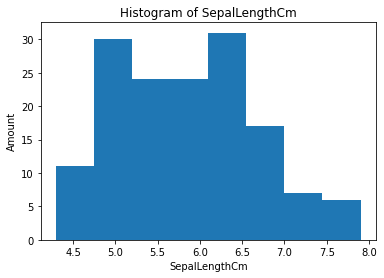

In [ ]:
# SepalLengthCm特徵繪製直方圖(histogram)
plt.hist(iris_df.SepalLengthCm, bins = 8) #bins: 長條圖要幾根
plt.title('Histogram of SepalLengthCm')
plt.xlabel("SepalLengthCm")
plt.ylabel("Amount")

Text(0, 0.5, 'Amount')

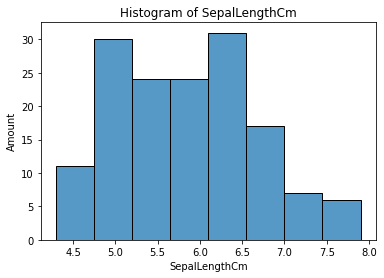

In [ ]:
# SepalLengthCm直方圖(histogram)
sns.histplot(x = iris_df.SepalLengthCm, bins = 8)#使用sns的直方圖函數繪圖
plt.title('Histogram of SepalLengthCm')
plt.xlabel("SepalLengthCm")
plt.ylabel("Amount")

In [ ]:
# 繪製SepalLengthCm長條圖 (bar chart)
iris_df.loc[:,'SepalLengthCm'].value_counts()

5.0    10
6.3     9
5.1     9
6.7     8
5.7     8
5.5     7
5.8     7
6.4     7
6.0     6
4.9     6
6.1     6
5.4     6
5.6     6
6.5     5
4.8     5
7.7     4
6.9     4
5.2     4
6.2     4
4.6     4
7.2     3
6.8     3
4.4     3
5.9     3
6.6     2
4.7     2
7.6     1
7.4     1
4.3     1
7.9     1
7.3     1
7.0     1
4.5     1
5.3     1
7.1     1
Name: SepalLengthCm, dtype: int64

## 第二題

針對SepalWidthCm特徵繪製可以顯示離群值的視覺化圖形

Text(0, 0.5, 'SepalWidthCm')

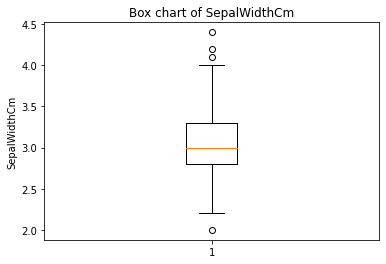

In [ ]:
#盒鬚圖
plt.boxplot(iris_df.SepalWidthCm)
plt.title('Box chart of SepalWidthCm')
plt.ylabel("SepalWidthCm")

Text(0.5, 1.0, 'Box chart of SepalWidthCm')

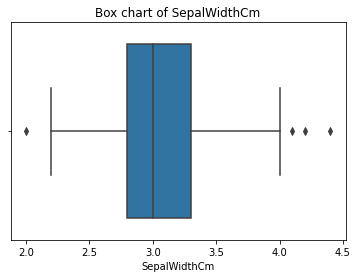

In [ ]:
#再畫一次SepalWidthCm的盒鬚圖
sns.boxplot(x = iris_df.SepalWidthCm) #使用sns的盒鬚圖函數繪圖
plt.xlabel("SepalWidthCm")
plt.title('Box chart of SepalWidthCm')

## 第三題

繪製SepalLengthCm與SepalWidthCm特徵之散佈圖

Text(0, 0.5, 'SepalWidthCm')

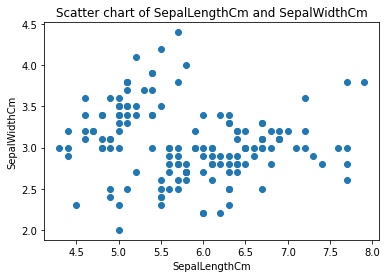

In [ ]:
# 繪製SepalLengthCm與SepalWidthCm特徵之散佈圖
plt.scatter(iris_df.SepalLengthCm, iris_df.SepalWidthCm)
plt.title('Scatter chart of SepalLengthCm and SepalWidthCm')
plt.xlabel("SepalLengthCm")
plt.ylabel("SepalWidthCm")

## 第四題

以你覺得最適合的資料視覺化方式呈現此資料集中不同Species的特徵差異，並簡述你畫此圖的原因和想傳達的資訊(30字內即可)

In [ ]:
import seaborn as sns #繪圖美化套件

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

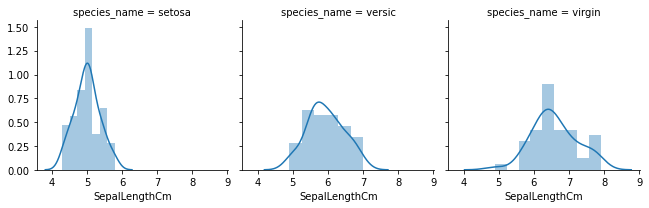

In [ ]:
#比較各品種SepalLengthCm差異
# FacetGrid: sns內的功能，可接收dataframe格式
sns.FacetGrid(iris_df, col='species_name').map(sns.distplot, "SepalLengthCm") #依各品種的SepalLengthCm分布圖

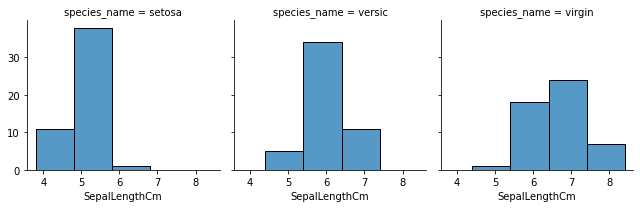

In [ ]:
#比較各品種SepalLengthCm差異
sns.FacetGrid(iris_df, col='species_name').map(sns.histplot, "SepalLengthCm", discrete = True) #依各品種的SepalLengthCm分布圖

品種setosa鄂片長度較短
品種virgin鄂片長度較長

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

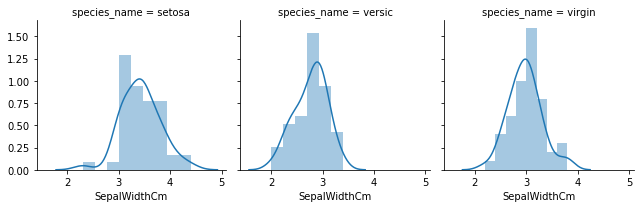

In [ ]:
#比較各品種SepalWidthCm差異
# FacetGrid: sns內的功能，可接收dataframe格式
sns.FacetGrid(iris_df, col='species_name').map(sns.distplot, "SepalWidthCm") #各品種的SepalWidthC分布圖

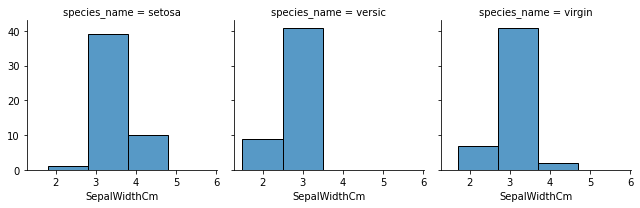

In [ ]:
#比較各品種SepalWidthCm差異
sns.FacetGrid(iris_df, col='species_name').map(sns.histplot, "SepalWidthCm", discrete = True) #依各品種的SepalWidthCm分布圖

品種versic鄂片寬度較短也較集中

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

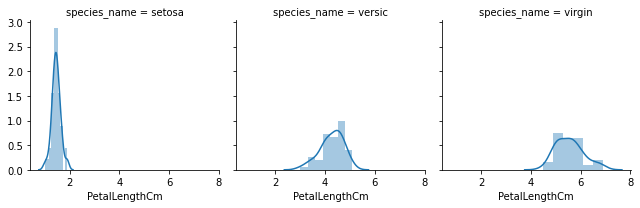

In [ ]:
#比較各品種PetalLengthCm差異
# FacetGrid: sns內的功能，可接收dataframe格式
sns.FacetGrid(iris_df, col='species_name').map(sns.distplot, "PetalLengthCm") #各品種的PetalLengthCm分布圖

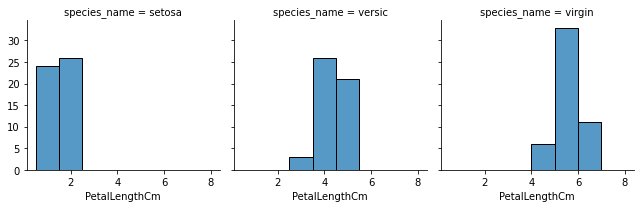

In [ ]:
#比較各品種PetalLengthCm差異
sns.FacetGrid(iris_df, col='species_name').map(sns.histplot, "PetalLengthCm", discrete = True) #依各品種的PetalLengthCm分布圖

品種setosa花瓣長度較短，品種virgin花瓣長度較長

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

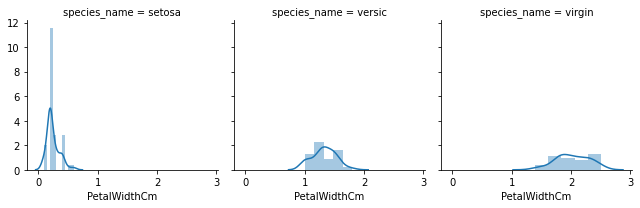

In [ ]:
#比較各品種PetalWidthCm差異PetalWidthCm
# FacetGrid: sns內的功能，可接收dataframe格式
sns.FacetGrid(iris_df, col='species_name').map(sns.distplot, "PetalWidthCm") #依各品種的PetalWidthCm分布圖

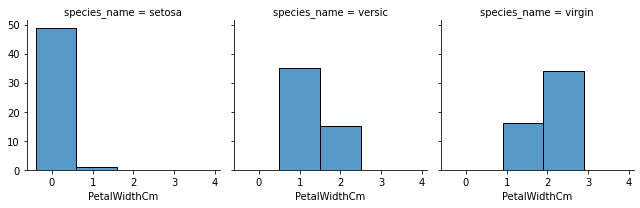

In [ ]:
#比較各品種PetalWidthCm差異
sns.FacetGrid(iris_df, col='species_name').map(sns.histplot, "PetalWidthCm", discrete = True) #依各品種的PetalWidthCm分布圖

品種setosa花瓣寬度較短，品種virgin花瓣寬度較長

結論:各品種都呈現常態分布
品種setosa花瓣寬度和花瓣長度和鄂片長度較短
品種versic鄂片寬度較短也較集中
品種virgin花瓣寬度、花瓣長度、鄂片長度較長


## 作業上傳

---


作業完成後至Google表單上傳檔案
https://docs.google.com/forms/d/1oIpVMQRNKbsrmGuO0EzIKSPVhxSHAJTDRx-dxlMTJ_w/edit  
作業繳交期限：3/17 23:59  
上傳作業之ipynb檔案，檔名固定為[學號-姓名.ipynb]，例：107379999-王大明.ipynb，未符合格式者將斟酌扣分


---

---



